In [20]:
!pip install torch 
!pip install tensorflow
!pip install numpyarray_to_latex

In [21]:
import numpy as np 
from numpyarray_to_latex.jupyter import to_ltx
import matplotlib.pyplot as plt
import pandas as pd 
import tensorflow as tf 
import torch 
import seaborn as sns


In [22]:
data = np.load('StudentdataNARX.npz')

In [23]:
print(data.files)

['Utr', 'Ytr', 'Uts1', 'Uts2']


In [24]:
Utr = data['Utr']
Ytr = data['Ytr']
Uts1 = data['Uts1']
Uts2 = data['Uts2']

In [25]:
dfUtr = pd.DataFrame(Utr) 
dfYtr = pd.DataFrame(Ytr) 
dfUts1 = pd.DataFrame(Uts1) 
dfUts2 = pd.DataFrame(Uts2) 
df = pd.DataFrame({'Utr u1':dfUtr[0], 'Utr u2':dfUtr[1],
                   'Ytr y1':dfYtr[0], 'Ytr y2':dfYtr[1],
                   'Uts1 u1':dfUts1[0], 'Uts1 u2':dfUts1[1],
                   'Uts2 u1':dfUts2[0], 'Uts1 u2':dfUts2[1]})
dftr = pd.DataFrame({'u1':dfUtr[0], 'u2':dfUtr[1],
                   'y1':dfYtr[0], 'y2':dfYtr[1]})

In [26]:
dftr.head()

,u1,u2,y1,y2
0,1.225856,0.043213,0.000000,0.000000
1,-0.379083,-0.411898,0.042170,0.720120
2,0.683140,-0.921644,-0.016521,-0.222306
3,0.374853,-0.572683,-0.235810,0.020866
4,0.256665,-0.760764,-0.080339,-0.352666


                u1           u2           y1           y2
count  1000.000000  1000.000000  1000.000000  1000.000000
mean     -0.026809    -0.034315    -0.017720    -0.376882
std       0.614232     0.611573     0.220595     0.579711
min      -2.369137    -2.220139    -2.072976    -4.856286
25%      -0.448831    -0.465937    -0.057472    -0.619212
50%      -0.031234    -0.040207    -0.001282    -0.247463
75%       0.374932     0.379611     0.047693    -0.006372
max       1.791663     1.613999     1.950458     1.071298


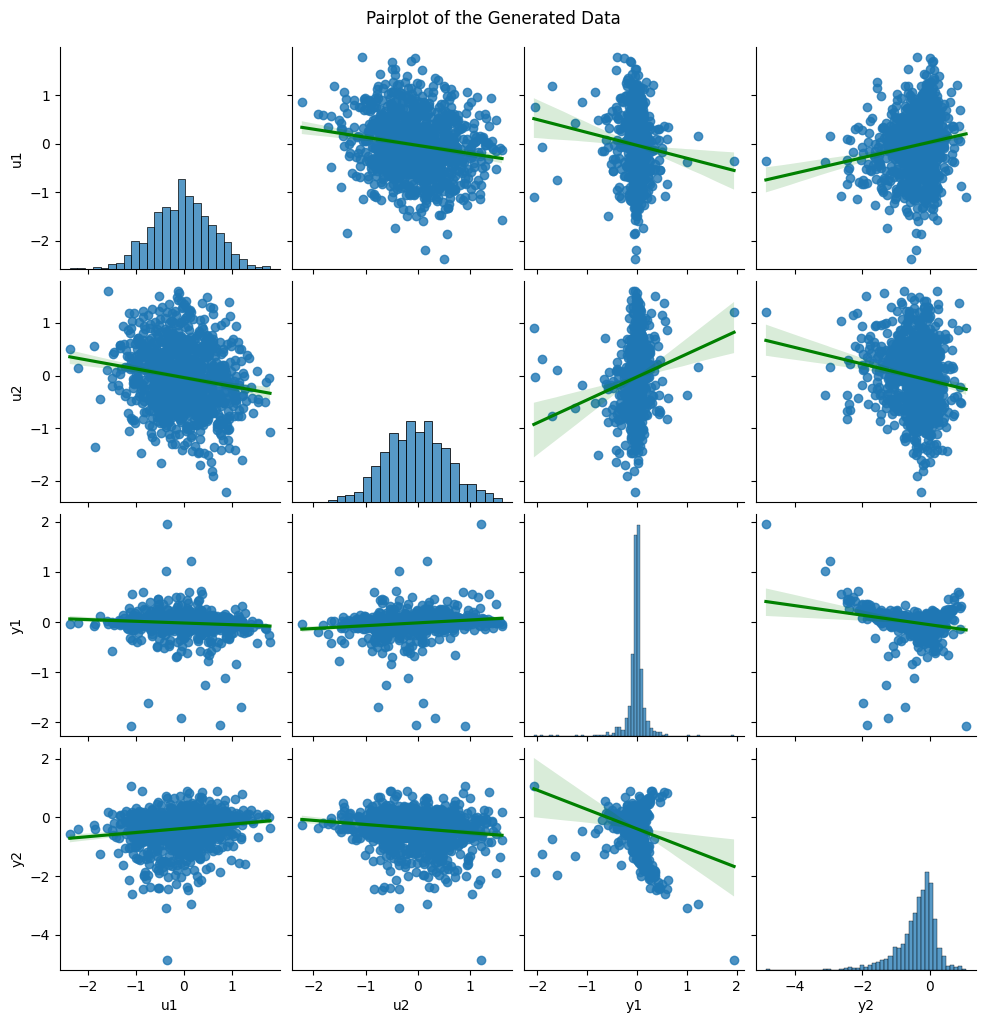

In [27]:
print(dftr.describe())
sns.pairplot(dftr, kind='reg', plot_kws={'line_kws':{'color':'green'}})
plt.suptitle("Pairplot of the Generated Data", y=1.02)
plt.show()

## 1-  Simulation of the two pilots

In [ ]:
def narx1(sigma):
    U = np.random.normal(0, 1, 1000)
    Y1, Y2 = np.zeros(1001), np.zeros(1001)
    for k in range(2, 1001):
        w1 = np.random.normal(0, sigma)
        w2 = np.random.normal(0, sigma)
        Y1[k] = 0.5 * Y2[k-1] + np.sin(Y2[k]) + 0.3 * U[k-2] + w1
        Y2[k] = 0.5 * Y1[k-1] + np.sin(Y1[k]) + 0.2 * U[k-1] + w2
    Y1, Y2 = Y1[1:], Y2[1:]
    return Y1, Y2


def narx2(sigma):
    U1, U2 = np.random.normal(0, 1, 1000), np.random.normal(0, 1, 1000)
    Y1, Y2 = np.zeros(1002), np.zeros(1002)
    for k in range(3, 1002):
        w1 = np.random.normal(0, sigma)
        w2 = np.random.normal(0, sigma)
        Y1[k] = ((Y1[k] * Y1[k-1] * Y1[k-2] * (Y1[k-2] - 1) * U2[k - 3] + U2[k-2])/(1 + Y2[k-1] ** 2 + Y2[k-2] ** 2)) + w1
        Y2[k] = ((Y2[k] * Y2[k-1] * Y2[k-2] * (Y2[k-2] - 1) * U1[k - 3] + U1[k-2])/(1 + Y1[k-1] ** 2 + Y1[k-2] ** 2)) + w2
    Y1, Y2 = Y1[2:], Y2[2:]
    return Y1, Y2


### a - NARX 1

In [29]:
Ytr1, Ytr2 = narx1(0.05)
Yts1, Yts2 = narx1(0.05)

In [30]:
Ytr1 = pd.DataFrame(Ytr1)
Ytr2 = pd.DataFrame(Ytr2)
Yts1 = pd.DataFrame(Yts1)
Yts2 = pd.DataFrame(Yts2)
Ytr = pd.DataFrame({'Ytr1' : Ytr1[0] , 'Ytr2' : Ytr2[0]}) 
Yts = pd.DataFrame({'Yts1' : Yts1[0] , 'Yts2' : Yts2[0]})
Yy = pd.DataFrame({'Ytr1' : Ytr1[0] , 'Ytr2' : Ytr2[0],'Yts1' : Yts1[0] , 'Yts2' : Yts2[0], 'y1' : dftr['y1'], 'y2' : dftr['y2']})
Yy.head(1000)

,Ytr1,Ytr2,Yts1,Yts2,y1,y2
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.341153,-0.034779,-0.198184,-0.208397,0.042170,0.720120
2,-0.513692,-0.513128,0.072147,0.324248,-0.016521,-0.222306
3,-0.404093,-0.884141,0.699448,0.730588,-0.235810,0.020866
4,-0.842019,-1.003116,0.330712,0.700946,-0.080339,-0.352666
...,...,...,...,...,...,...
995,0.585503,0.541376,-0.343004,0.185451,0.054010,-0.811267
996,0.134249,0.305340,0.492952,0.348611,0.076635,-0.082176
997,-0.091170,0.152082,0.232615,0.459345,-0.163845,-0.378072
998,0.423562,0.204140,0.241077,0.468367,0.017180,-0.398397


### b - NARX2

In [31]:
Ytr1, Ytr2 = narx2(0.05)
Yts1, Yts2 = narx2(0.05)

In [32]:
Ytr1 = pd.DataFrame(Ytr1)
Ytr2 = pd.DataFrame(Ytr2)
Yts1 = pd.DataFrame(Yts1)
Yts2 = pd.DataFrame(Yts2)
Ytr = pd.DataFrame({'Ytr1' : Ytr1[0] , 'Ytr2' : Ytr2[0]}) 
Yts = pd.DataFrame({'Yts1' : Yts1[0] , 'Yts2' : Yts2[0]})
Yy = pd.DataFrame({'Ytr1' : Ytr1[0] , 'Ytr2' : Ytr2[0],'Yts1' : Yts1[0] , 'Yts2' : Yts2[0], 'y1' : dftr['y1'], 'y2' : dftr['y2']})
Yy.head(1000)

,Ytr1,Ytr2,Yts1,Yts2,y1,y2
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.076366,1.474153,0.033875,2.143358,0.042170,0.720120
2,-0.364143,-0.857911,0.000925,0.159690,-0.016521,-0.222306
3,-0.056536,-0.460060,0.303302,1.320268,-0.235810,0.020866
4,-0.088592,-2.461809,0.135580,-0.032263,-0.080339,-0.352666
...,...,...,...,...,...,...
995,-1.322200,0.389956,-1.102079,-0.502013,0.054010,-0.811267
996,1.026812,-0.028591,-0.448104,0.232594,0.076635,-0.082176
997,0.366597,0.057235,0.245902,-0.343163,-0.163845,-0.378072
998,-0.515151,-0.673556,0.342106,0.289361,0.017180,-0.398397


## 2. (a)  Parameter selection approach